# 1. Gridworld: Problem Description

We explore a standard $5 \times 5$ gridworld environment to study state-value functions. In this setup, an agent moves through the grid by selecting one of four possible actions—**Up, Down, Left, Right**—with equal probability ($\pi = 0.25$).



### 1.1 Transition Dynamics and Rewards
The environment's physics are defined by specific reward signals and transition rules:

* **Teleportation (Special States):**
    * **State A (0, 1):** Any action taken at this position instantly transports the agent to **State A' (4, 1)** with a reward of **+10**.
    * **State B (0, 3):** Any action taken at this position instantly transports the agent to **State B' (2, 3)** with a reward of **+5**.
* **Boundary Penalties:**
    * If an action would move the agent outside the boundaries of the grid, the agent remains in its current position and receives a penalty reward of **-1**.
* **Standard Movement:**
    * For all other transitions that remain within the grid, the reward is **0**.

### 1.2 Objective: Policy Evaluation
Our goal is to compute the **state-value function** $v(s)$ under this uniform random policy. This function represents the expected return (cumulative discounted reward) starting from state $s$:

$$v(s) = \mathbb{E}[G_0 \mid S_0 = s]$$

By solving this, we visualize how the presence of high-reward "teleporters" and negative "walls" influences the long-term value of every coordinate in the system.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 2. Implementation: Environment Setup

To simulate the Gridworld, we first define the state-action space and the physical "rules" that govern agent movement and rewards.

### 2.1 State and Action Space
* **States ($S$):** A set of 25 discrete coordinates $(i, j)$ where $i, j \in \{0, 1, 2, 3, 4\}$.
* **Actions ($A$):** Four possible movements—Up, Down, Left, and Right.
* **Policy ($\pi$):** A uniform random policy where $\pi(a|s) = 0.25$ for all actions.
* **Discount Factor ($\gamma$):** Set to $0.9$ to ensure the infinite horizon sum of rewards converges.

### 2.2 Transition Function
The `transition(s, a)` function acts as the environment's internal model. It handles three specific types of events:
1. **Teleportation:** Explicitly checking if the agent is on state $A$ or $B$ before any other movement logic.
2. **Boundary Conditions:** Checking if the resulting coordinate $(nr, nc)$ falls outside the $5 \times 5$ grid.
3. **Standard Moves:** Returning the new coordinate with a neutral reward (0) if no special conditions are met.

In [2]:
# ----- Setup -----
states = [(i, j) for i in range(5) for j in range(5)]
actions = [(0,1), (0,-1), (1,0), (-1,0)]
pi = 1/4
gamma = 0.9
tolerance = 1e-6

# initialize V(s)=0
V = {s: 0.0 for s in states}
V_new = V.copy()


def transition(s, a):
    r, c = s
    dr, dc = a
    nr, nc = r + dr, c + dc

    # ----- Teleporters -----
    # Must check BEFORE boundary check because teleporter logic
    # depends only on the current state, not the next location.

    # A -> A'
    if s == (0, 1):
        return (4, 1), 10

    # B -> B'
    if s == (0, 3):
        return (2, 3), 5

    # ----- Standard movement -----
    # If out of bounds → stay + reward -1
    if not (0 <= nr < 5 and 0 <= nc < 5):
        return s, -1

    # Otherwise normal move, reward = 0
    return (nr, nc), 0


In [8]:

def plot_value_table(V, m=5, n=5):
    """
    V: dictionary with keys (i, j) and values = state values
    """

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axis('off')  # remove axes

    # Build table data row by row
    table_data = []
    for i in range(m):
        row = []
        for j in range(n):
            row.append(f"{V[(i,j)]:.2f}")   # format numbers as 2 decimals
        table_data.append(row)

    # Create table
    table = ax.table(cellText=table_data, 
                     loc='center',
                     cellLoc='center')

    # Make cells square and nice looking
    table.scale(1, 2)
    for cell in table._cells:
        table._cells[cell].set_edgecolor("black")

    plt.title("State-Value Function (Grid 5×5)", pad=20)
    plt.show()



# 3. Method 1: Exact Solution via Matrix Inversion

The value function under a fixed policy satisfies the **Bellman expectation equation**:

$$v_\pi(s) = \sum_a \pi(a \mid s) \sum_{s', r} p(s', r \mid s, a) \Big[ r + \gamma v_\pi(s') \Big]$$



### 3.1 Vector Representation
Since the gridworld has a finite number of states ($25$), we can represent the value function as a vector $\mathbf{v} \in \mathbb{R}^{25}$. This allows us to rewrite the Bellman equation in matrix form:

$$\mathbf{v} = \mathbf{r} + \gamma \mathbf{P}\mathbf{v}$$

Where:
* **$\mathbf{P}$** is the transition probability matrix, where $P_{ij}$ is the probability of moving from state $i$ to state $j$.
* **$\mathbf{r}$** is the vector of expected immediate rewards for each state.
* **$\mathbf{v}$** is the value vector we wish to solve for.

### 3.2 Analytical Solution
By rearranging the terms into a linear system, we can isolate $\mathbf{v}$:

$$(\mathbf{I} - \gamma \mathbf{P})\,\mathbf{v} = \mathbf{r}$$

Thus, the exact value function is obtained by inverting the matrix:

$$\mathbf{v} = (\mathbf{I} - \gamma\mathbf{P})^{-1} \mathbf{r}$$

### 3.3 Computational Considerations
While matrix inversion has a computational complexity of $O(n^3)$, making it impractical for large-scale state spaces, it provides an **exact analytical solution** for smaller environments like our $5 \times 5$ gridworld. This serves as a "ground truth" to which iterative or sampling-based methods can be compared.

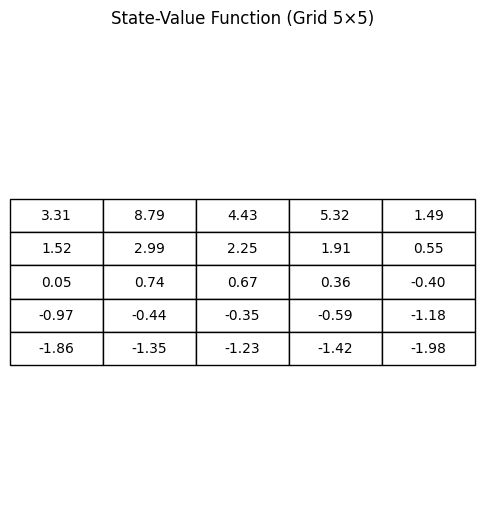

In [5]:
# Create a mapping from (r, c) to a single index (0-24)
state_to_idx = {s: i for i, s in enumerate(states)}

# Initialize Matrix P (Transitions) and Vector R (Expected Rewards)
P = np.zeros((25, 25))
R = np.zeros(25)

for s in states:
    idx_s = state_to_idx[s]
    for a in actions:
        next_s, reward = transition(s, a)
        idx_next = state_to_idx[next_s]
        
        # Build the transition matrix: sum of (prob * transition)
        P[idx_s, idx_next] += pi
        # Build the expected reward vector: sum of (prob * reward)
        R[idx_s] += pi * reward

# Solve the linear system: (I - gamma * P) * V = R
# V = inv(I - gamma * P) * R
I = np.eye(25)
V_matrix = np.linalg.solve(I - gamma * P, R)

# Map back to dictionary format for your plotting function
V_final = {states[i]: V_matrix[i] for i in range(25)}
plot_value_table(V_final)

# 4. Method 2: Iterative Policy Evaluation (Dynamic Programming)

While matrix inversion provides an analytical solution, we also implement **Iterative Policy Evaluation**. This is a Dynamic Programming (DP) algorithm that turns the Bellman expectation equation into an iterative update rule.

### 4.1 The Update Rule
The algorithm starts with an initial guess $V_0(s) = 0$ for all states and improves the estimate by "sweeping" through the state space. For each state, we calculate:

$$V_{k+1}(s) = \sum_{a \in \mathcal{A}} \pi(a|s) \left[ \mathcal{R}_s^a + \gamma V_k(s_{next}) \right]$$

### 4.2 Convergence and Tolerance
The algorithm is **synchronous**: it stores new values in `V_new` and only updates the main `V` table after a full pass through all 25 states. We define a convergence threshold ($\theta = 10^{-6}$):

$$\Delta = \max_{s \in \mathcal{S}} |V_{k+1}(s) - V_k(s)|$$

The loop terminates when $\Delta < \theta$, indicating that the value function has reached a fixed-point equilibrium and represents the true value of the policy.

### 4.3 Advantages of DP
Unlike sampling-based methods (like Monte Carlo), this approach:
* Has **Zero Variance**, as it uses the exact model of the environment.
* **Bootstraps**, meaning it updates estimates based on other existing estimates, leading to much faster convergence than independent sampling.

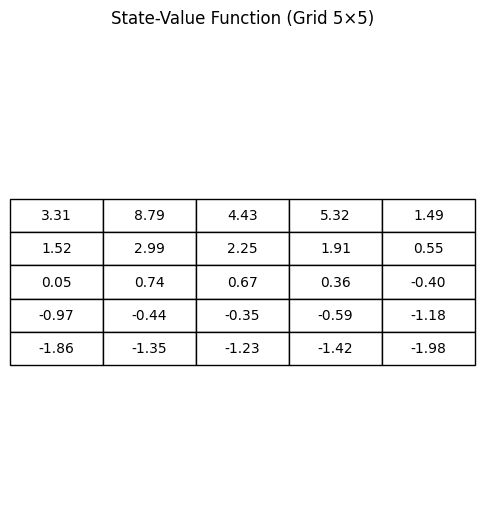

In [9]:
# ----- Iterative Policy Evaluation -----
while True:
    delta = 0

    for s in states:
        v = 0

        for a in actions:
            next_s, reward = transition(s, a)  # your function that does A,B,out-of-bound logic
            v += pi * (reward + gamma * V[next_s])

        V_new[s] = v
        delta = max(delta, abs(V_new[s] - V[s]))

    # copy new values into old values
    V = V_new.copy()

    # check convergence
    if delta < tolerance:
        break





plot_value_table(V)



